In [31]:
import os
import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
dj.config.load("/home/sgao/source/spyglass/notebooks/dj_local_conf.json")  # load config for database connection info

import spyglass.common as sgc
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
import spyglass.lfp as sglfp
import spyglass.lfp as lfp
from spyglass.position import PositionOutput
from spyglass.lfp.v1.lfp_artifact import (
    LFPArtifactDetection,
    LFPArtifactDetectionParameters,
    LFPArtifactDetectionSelection,
)
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

# ignore datajoint+jupyter async warnings
import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

[2026-10-07 13:22:49,661][INFO]: DataJoint is configured from /home/sgao/source/spyglass/notebooks/dj_local_conf.json


In [32]:
import pynwb

nwb_file_name = "Embry20260604_.nwb"

io = pynwb.NWBHDF5IO(
    "/stelmo/nwb/raw/Embry20260604_.nwb",
    mode="r"
)

nwbf = io.read()

In [33]:
import pandas as pd

nwb_file_name = "Embry20260604_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

results = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer",
        }
    ).fetch1_dataframe()

    results.append({
        "session_number": session_number,
        "session": session,
        "n_ripples": len(ripple_times),
    })

ripple_counts = pd.DataFrame(results)

ripple_counts

,session_number,session,n_ripples
0,1,01_s1,2157
1,2,03_s2,3079
2,3,05_s3,3223
3,4,07_s4,3000
4,5,09_s5,3226
5,6,11_s6,3012


In [34]:
for session in sleep_sessions:
    rel = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    )

    print(session, len(rel))

01_s1 1
03_s2 1
05_s3 1
07_s4 1
09_s5 1
11_s6 2


In [35]:
(
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": nwb_file_name,
        "target_interval_list_name": "11_s6",
        "ripple_param_name": "default_trodes",
    }
).fetch(as_dict=True)

[{'lfp_merge_id': UUID('d8480f89-1050-98ca-b0b8-f9efa639a7d7'),
  'filter_name': 'Ripple 150-250 Hz DMR',
  'filter_sampling_rate': 1034,
  'nwb_file_name': 'Embry20260604_.nwb',
  'target_interval_list_name': '11_s6',
  'lfp_band_sampling_rate': 1034,
  'group_name': 'CA1 Pyramidal Layer',
  'ripple_param_name': 'default_trodes',
  'pos_merge_id': UUID('d7bbad12-5aae-268d-77b3-e8b5216336fb'),
  'analysis_file_name': 'Embry20260604_HSVUBWXUKS.nwb',
  'ripple_times_object_id': '0f1cb6e6-e4f0-4122-a7f8-c8152d988fa0'},
 {'lfp_merge_id': UUID('d8480f89-1050-98ca-b0b8-f9efa639a7d7'),
  'filter_name': 'Ripple 150-250 Hz DMR',
  'filter_sampling_rate': 1034,
  'nwb_file_name': 'Embry20260604_.nwb',
  'target_interval_list_name': '11_s6',
  'lfp_band_sampling_rate': 1034,
  'group_name': 'Ripple Detection Channels',
  'ripple_param_name': 'default_trodes',
  'pos_merge_id': UUID('d7bbad12-5aae-268d-77b3-e8b5216336fb'),
  'analysis_file_name': 'Embry20260604_222W0W6XSC.nwb',
  'ripple_times_obj

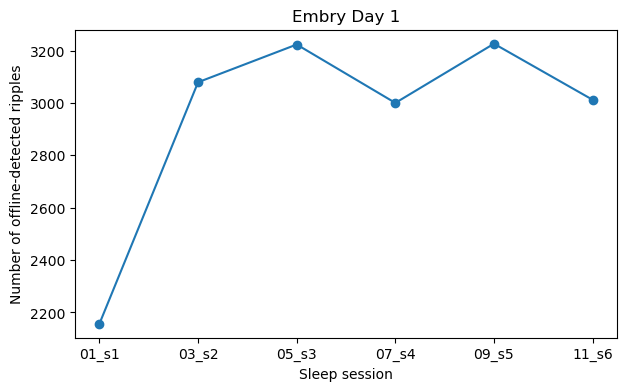

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    ripple_counts["session"],
    ripple_counts["n_ripples"],
    marker="o"
)

plt.xlabel("Sleep session")
plt.ylabel("Number of offline-detected ripples")
plt.title("Embry Day 1")

plt.show()

In [37]:
import pandas as pd

nwb_file_name = "Embry20260604_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

results = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer",
        }
    ).fetch1_dataframe()

    n_ripples = len(ripple_times)

    first_ripple = ripple_times["start_time"].min()
    last_ripple = ripple_times["end_time"].max()

    duration_sec = last_ripple - first_ripple
    duration_min = duration_sec / 60

    ripple_rate = n_ripples / duration_min

    results.append({
        "session_number": session_number,
        "session": session,
        "n_ripples": n_ripples,
        "duration_min": duration_min,
        "ripples_per_min": ripple_rate,
    })

ripple_summary = pd.DataFrame(results)

ripple_summary

,session_number,session,n_ripples,duration_min,ripples_per_min
0,1,01_s1,2157,39.895298,54.066522
1,2,03_s2,3079,40.102591,76.778081
2,3,05_s3,3223,40.026111,80.522437
3,4,07_s4,3000,39.955773,75.083017
4,5,09_s5,3226,40.005944,80.638016
5,6,11_s6,3012,41.665694,72.289687


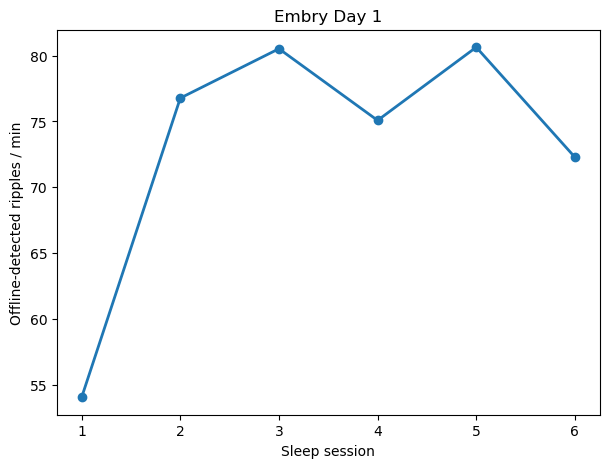

In [38]:
import matplotlib.pyplot as plt

ripple_summary["session_number"] = [1, 2, 3, 4, 5, 6]

plt.figure(figsize=(7, 5))

plt.plot(
    ripple_summary["session_number"],
    ripple_summary["ripples_per_min"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Offline-detected ripples / min")
plt.title("Embry Day 1")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.show()
ripple_summary_day1 = ripple_summary.copy()
ripple_summary.to_csv("embry_ripple_summary.csv", index=False)

duration

In [39]:
import pandas as pd

nwb_file_name = "Embry20260604_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

all_ripples = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer",
        }
    ).fetch1_dataframe().copy()

    ripple_times["session_number"] = session_number
    ripple_times["session"] = session

    all_ripples.append(ripple_times)

all_ripples = pd.concat(all_ripples, ignore_index=True)

all_ripples

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,session_number,session
0,1.780596e+09,1.780596e+09,0.105369,2.790871,1.348181,0.816621,5.256470,0.100952,0.142980,0.394408,3.742431,3.318021,3.742431,3.318021,3.380920,3.431112,1,01_s1
1,1.780596e+09,1.780596e+09,0.063801,2.787734,1.689131,1.373446,3.975411,0.026479,0.109361,0.290312,0.984476,3.077344,3.077344,0.984476,2.075420,2.049695,1,01_s1
2,1.780596e+09,1.780596e+09,0.061868,2.679102,1.557478,1.098431,4.165602,0.004530,0.097834,0.277301,1.517545,0.637118,1.517545,0.637118,0.852533,0.935731,1,01_s1
3,1.780596e+09,1.780596e+09,0.087968,2.332895,1.565574,1.244806,3.507093,0.021869,0.139202,0.346986,0.681723,0.923559,0.923559,0.516335,0.601197,0.633376,1,01_s1
4,1.780596e+09,1.780596e+09,0.107302,2.908669,1.241661,0.686753,4.187635,0.017105,0.134414,0.324615,0.956692,1.026244,1.026244,0.608413,0.762600,0.779988,1,01_s1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17692,1.780617e+09,1.780617e+09,0.086035,4.533516,2.216458,1.532622,6.350337,0.003589,0.192829,0.745019,0.033282,0.039920,0.039920,0.033282,0.034217,0.035026,6,11_s6
17693,1.780617e+09,1.780617e+09,0.064768,2.741321,1.587241,1.262049,3.607599,0.023164,0.104302,0.257426,0.041903,0.038578,0.041903,0.038578,0.039499,0.039735,6,11_s6
17694,1.780617e+09,1.780617e+09,0.055101,2.321488,1.447851,0.898960,3.593707,0.020017,0.081134,0.198682,0.110757,0.126840,0.127501,0.110757,0.123507,0.121954,6,11_s6
17695,1.780617e+09,1.780617e+09,0.062835,2.531494,1.611928,1.142138,4.156902,0.033249,0.102801,0.269541,0.075346,0.591095,0.591095,0.075346,0.266927,0.288973,6,11_s6


In [40]:
all_ripples["duration_ms"] = (
    all_ripples["end_time"] - all_ripples["start_time"]
) * 1000

duration_summary = (
    all_ripples
    .groupby("session_number")["duration_ms"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        std="std"
    )
    .reset_index()
)

duration_summary
duration_summary.to_csv("embry_duration_summary.csv", index=False)

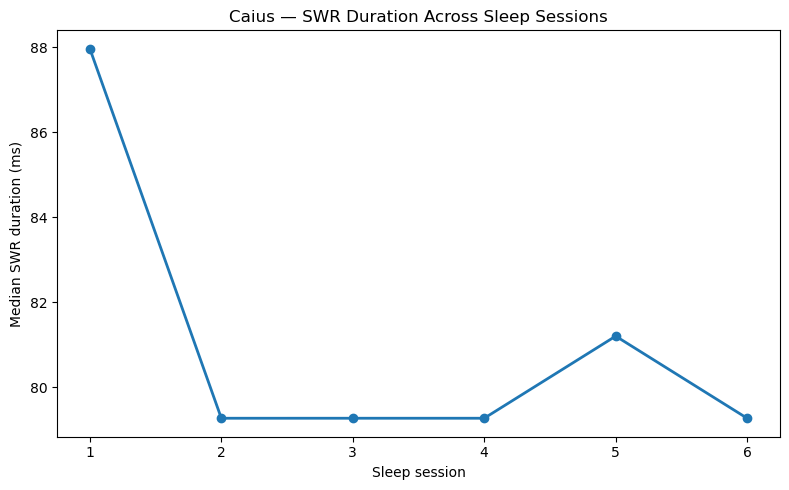

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    duration_summary["session_number"],
    duration_summary["median"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Median SWR duration (ms)")
plt.title("Caius — SWR Duration Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.show()

In [42]:
amplitude_summary = (
    all_ripples
    .groupby("session_number")["max_zscore"]
    .agg(
        n="count",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        std="std"
    )
    .reset_index()
)

amplitude_summary["IQR"] = (
    amplitude_summary["q75"] -
    amplitude_summary["q25"]
)

amplitude_summary
amplitude_summary.to_csv("embry_amplitude_summary.csv", index=False)

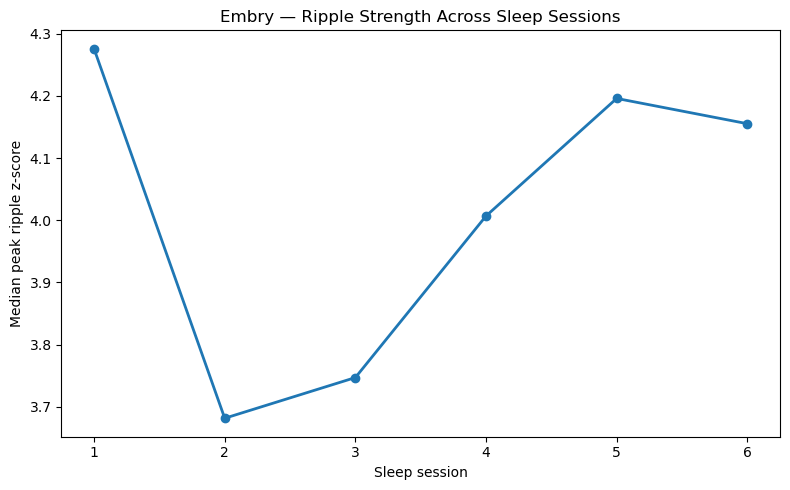

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    amplitude_summary["session_number"],
    amplitude_summary["median"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Median peak ripple z-score")
plt.title("Embry — Ripple Strength Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.show()